In [1]:
# ===============================
# Core Libraries
# ===============================
import numpy as np
import pandas as pd
import os
import warnings
warnings.filterwarnings("ignore")

# ===============================
# Machine Learning
# ===============================
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# ===============================
# Model Persistence
# ===============================
import joblib


In [4]:
# ===============================
# Collect Parquet Files (Local)
# ===============================

import os

DATASET_DIR = "./dataset"   # relative path from TRACEFI root

ALLOWED_PREFIXES = ["DNS", "LDAP", "NTP", "UDP", "Syn"]

parquet_files = []

for file in os.listdir(DATASET_DIR):
    if file.endswith(".parquet"):
        # ignore any unwanted experimental files if added later
        if "UDPLag" in file:
            continue

        # select only allowed attack types
        for prefix in ALLOWED_PREFIXES:
            if file.startswith(prefix):
                parquet_files.append(os.path.join(DATASET_DIR, file))
                break

print("Selected parquet files:")
for f in parquet_files:
    print(f)

print(f"\nTotal files selected: {len(parquet_files)}")


Selected parquet files:
./dataset\DNS-testing.parquet
./dataset\DNS-training.parquet
./dataset\LDAP-testing.parquet
./dataset\LDAP-training.parquet
./dataset\NTP-testing.parquet
./dataset\NTP-training.parquet
./dataset\Syn-testing.parquet
./dataset\Syn-training.parquet
./dataset\UDP-testing.parquet
./dataset\UDP-training.parquet

Total files selected: 10


In [5]:
# ===============================
# Verify Collected Parquet Files
# ===============================

# Extract attack prefixes from filenames (for logging only)
file_prefixes = sorted(
    set(os.path.basename(f).split("-")[0] for f in parquet_files)
)

print("Attack types included in dataset:")
for p in file_prefixes:
    print("-", p)

print(f"\nTotal parquet files used: {len(parquet_files)}")


Attack types included in dataset:
- DNS
- LDAP
- NTP
- Syn
- UDP

Total parquet files used: 10


In [6]:
# ===============================
# Load and Merge Parquet Files
# ===============================

dfs = []

for file in parquet_files:
    df_part = pd.read_parquet(file)
    dfs.append(df_part)

df = pd.concat(dfs, ignore_index=True)

# ===============================
# Initial Inspection
# ===============================

print("Combined dataset shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

# Detect label column automatically (safe check)
possible_label_cols = ["label", "Label", "class", "Class"]

label_col = None
for col in possible_label_cols:
    if col in df.columns:
        label_col = col
        break

print("\nDetected label column:", label_col)

# Distribution check
if label_col:
    print("\nLabel distribution:")
    print(df[label_col].value_counts())
else:
    print("❌ No label column detected — STOP and check dataset")


Combined dataset shape: (393775, 78)

Columns:
 ['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count',

In [7]:
# ===============================
# Step 1.5: Binary Label Conversion
# ===============================

# Convert multi-class labels to binary
df["binary_label"] = df["Label"].apply(
    lambda x: 0 if x.lower() == "benign" else 1
)

print("Binary label distribution:")
print(df["binary_label"].value_counts())


Binary label distribution:
binary_label
1    322836
0     70939
Name: count, dtype: int64


In [8]:
# ===============================
# Step 1.6: Drop Leakage Columns
# ===============================

leakage_columns = [
    "Flow ID",
    "Source IP",
    "Destination IP",
    "Timestamp"
]

# Drop only if they exist (safe)
df.drop(
    columns=[col for col in leakage_columns if col in df.columns],
    inplace=True
)

print("Remaining columns after dropping leakage columns:")
print(df.shape)


Remaining columns after dropping leakage columns:
(393775, 79)


In [9]:
# ===============================
# Step 1.7: Handle NaN and Infinite Values
# ===============================

# Replace infinite values with NaN
df.replace([np.inf, -np.inf], np.nan, inplace=True)

# Drop rows with NaN values
df.dropna(inplace=True)

print("Dataset shape after cleaning NaN/Inf:", df.shape)


Dataset shape after cleaning NaN/Inf: (393775, 79)


In [10]:
print("Any NaN left?", df.isna().sum().sum())


Any NaN left? 0


In [11]:
# ===============================
# Separate Features and Target
# ===============================

X = df.drop(columns=["binary_label"])
y = df["binary_label"]

print("Feature matrix shape:", X.shape)
print("Target shape:", y.shape)


Feature matrix shape: (393775, 78)
Target shape: (393775,)


In [14]:
# ===============================
# Step 1.8.5: Remove Non-Numeric Features
# ===============================

# Identify non-numeric columns
non_numeric_cols = X.select_dtypes(include=["object", "category"]).columns.tolist()

print("Non-numeric columns detected:")
for col in non_numeric_cols:
    print("-", col)

# Drop non-numeric columns
X = X.drop(columns=non_numeric_cols)

print("\nFeature matrix shape after dropping non-numeric columns:", X.shape)


Non-numeric columns detected:
- Label

Feature matrix shape after dropping non-numeric columns: (393775, 77)


In [15]:
# ===============================
# Step 1.9: Feature Selection
# ===============================

from sklearn.ensemble import ExtraTreesClassifier

selector = ExtraTreesClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

selector.fit(X, y)

# Get feature importance
importances = pd.Series(
    selector.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

TOP_N = 15
selected_features = importances.head(TOP_N).index.tolist()

print("Top selected features:")
for f in selected_features:
    print("-", f)

# Reduce feature matrix
X = X[selected_features]

print("\nReduced feature matrix shape:", X.shape)


Top selected features:
- URG Flag Count
- Fwd Packet Length Mean
- Avg Fwd Segment Size
- Down/Up Ratio
- Packet Length Min
- Protocol
- Bwd Packet Length Min
- CWE Flag Count
- ACK Flag Count
- Fwd Packet Length Min
- Packet Length Mean
- Avg Bwd Segment Size
- Bwd Packet Length Mean
- Fwd Packet Length Max
- Avg Packet Size

Reduced feature matrix shape: (393775, 15)


In [16]:
# ===============================
# Step 1.10: Train-Test Split
# ===============================

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training set shape:", X_train.shape, y_train.shape)
print("Testing set shape :", X_test.shape, y_test.shape)

print("\nTraining label distribution:")
print(y_train.value_counts())

print("\nTesting label distribution:")
print(y_test.value_counts())


Training set shape: (315020, 15) (315020,)
Testing set shape : (78755, 15) (78755,)

Training label distribution:
binary_label
1    258269
0     56751
Name: count, dtype: int64

Testing label distribution:
binary_label
1    64567
0    14188
Name: count, dtype: int64


In [17]:
# ===============================
# Step 1.11: Train Random Forest
# ===============================

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    min_samples_split=2,
    min_samples_leaf=1,
    class_weight="balanced",  # IMPORTANT for imbalance
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

print("✅ Random Forest training completed")


✅ Random Forest training completed


In [18]:
# ===============================
# Step 1.12: Model Evaluation
# ===============================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Predictions
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print("Model Performance:")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")
print(f"ROC-AUC   : {roc_auc:.4f}")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Model Performance:
Accuracy  : 0.9970
Precision : 0.9998
Recall    : 0.9966
F1-score  : 0.9982
ROC-AUC   : 0.9998

Confusion Matrix:
[[14172    16]
 [  218 64349]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99     14188
           1       1.00      1.00      1.00     64567

    accuracy                           1.00     78755
   macro avg       0.99      1.00      0.99     78755
weighted avg       1.00      1.00      1.00     78755



In [19]:
# ===============================
# Step 1.13: Save Model Artifacts
# ===============================

import joblib

joblib.dump(rf_model, "tracefi_rf_model.pkl")
joblib.dump(selected_features, "tracefi_selected_features.pkl")

print("✅ Model and feature list saved successfully")


✅ Model and feature list saved successfully


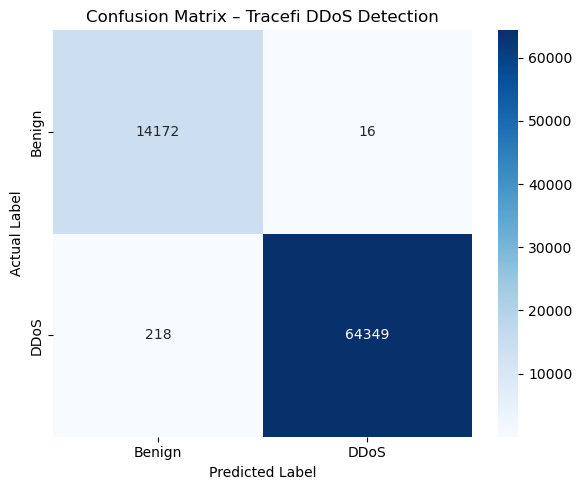

In [20]:
# ===============================
# Confusion Matrix Visualization
# ===============================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cmatrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cmatrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Benign", "DDoS"],
    yticklabels=["Benign", "DDoS"]
)

plt.title("Confusion Matrix – Tracefi DDoS Detection")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.tight_layout()
plt.show()


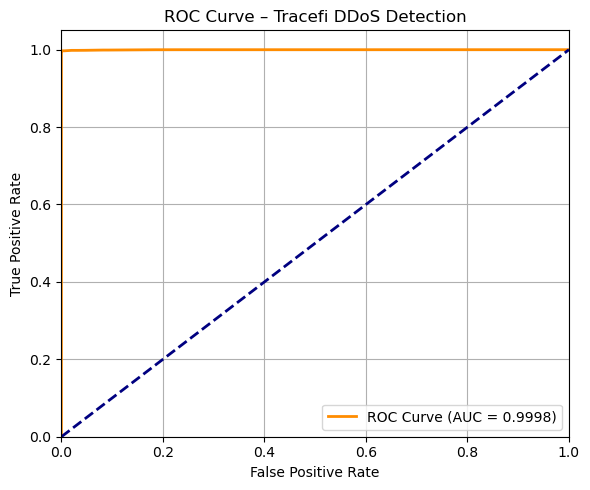

In [21]:
# ===============================
# ROC Curve
# ===============================

from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="darkorange", lw=2,
         label=f"ROC Curve (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Tracefi DDoS Detection")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


In [22]:
# ===============================
# Step 2.1: Load Model Artifacts
# ===============================

import joblib
import numpy as np
import pandas as pd

rf_model = joblib.load("tracefi_rf_model.pkl")
selected_features = joblib.load("tracefi_selected_features.pkl")

print("Model loaded successfully")
print("Selected features:", selected_features)


Model loaded successfully
Selected features: ['URG Flag Count', 'Fwd Packet Length Mean', 'Avg Fwd Segment Size', 'Down/Up Ratio', 'Packet Length Min', 'Protocol', 'Bwd Packet Length Min', 'CWE Flag Count', 'ACK Flag Count', 'Fwd Packet Length Min', 'Packet Length Mean', 'Avg Bwd Segment Size', 'Bwd Packet Length Mean', 'Fwd Packet Length Max', 'Avg Packet Size']


In [23]:
# ===============================
# Step 2.2: Simulated Real-Time Stream
# ===============================

# Convert test set to a stream
X_stream = X_test.copy().reset_index(drop=True)
y_stream = y_test.reset_index(drop=True)

print("Simulated stream size:", X_stream.shape)


Simulated stream size: (78755, 15)


In [24]:
# ===============================
# Step 2.3: Prediction Function
# ===============================

THRESHOLD = 0.7  # confidence threshold

def predict_ddos(flow_features):
    """
    flow_features: pandas Series with selected features
    """
    flow_df = pd.DataFrame([flow_features], columns=selected_features)

    prob = rf_model.predict_proba(flow_df)[0][1]
    prediction = 1 if prob >= THRESHOLD else 0

    return prediction, prob


In [25]:
# ===============================
# Step 2.4: Real-Time Detection Loop
# ===============================

for i in range(20):  # simulate first 20 flows
    flow = X_stream.iloc[i]
    true_label = y_stream.iloc[i]

    pred, confidence = predict_ddos(flow)

    status = "DDoS ATTACK" if pred == 1 else "NORMAL"

    print(
        f"Flow {i:03d} | "
        f"Prediction: {status} | "
        f"Confidence: {confidence:.3f} | "
        f"Actual: {'DDoS' if true_label == 1 else 'Benign'}"
    )


Flow 000 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 001 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 002 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 003 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 004 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 005 | Prediction: NORMAL | Confidence: 0.000 | Actual: Benign
Flow 006 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 007 | Prediction: NORMAL | Confidence: 0.000 | Actual: Benign
Flow 008 | Prediction: NORMAL | Confidence: 0.000 | Actual: Benign
Flow 009 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 010 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 011 | Prediction: NORMAL | Confidence: 0.000 | Actual: Benign
Flow 012 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 013 | Prediction: DDoS ATTACK | Confidence: 1.000 | Actual: DDoS
Flow 014 | Prediction: DDoS ATTA

In [26]:
# ===============================
# Step 2.5: Sliding Window Detection
# ===============================

WINDOW_SIZE = 10
ATTACK_COUNT_THRESHOLD = 5

window = []

for i in range(50):
    flow = X_stream.iloc[i]
    pred, confidence = predict_ddos(flow)

    window.append(pred)

    if len(window) > WINDOW_SIZE:
        window.pop(0)

    if sum(window) >= ATTACK_COUNT_THRESHOLD:
        print(f"🚨 DDoS CONFIRMED at flow {i} (window-based)")
        window.clear()


🚨 DDoS CONFIRMED at flow 4 (window-based)
🚨 DDoS CONFIRMED at flow 13 (window-based)
🚨 DDoS CONFIRMED at flow 18 (window-based)
🚨 DDoS CONFIRMED at flow 23 (window-based)
🚨 DDoS CONFIRMED at flow 29 (window-based)
🚨 DDoS CONFIRMED at flow 34 (window-based)
🚨 DDoS CONFIRMED at flow 39 (window-based)
🚨 DDoS CONFIRMED at flow 46 (window-based)


In [27]:
import requests

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json={}
)

print(response.json())


{'error': 'No input data provided'}


In [28]:
sample = X_test.iloc[0].to_dict()

response = requests.post(
    "http://127.0.0.1:5000/predict",
    json=sample
)

print(response.json())


{'confidence': 1.0, 'prediction': 'DDoS'}


In [29]:
# Separate benign and attack samples
attack_samples = X_test[y_test == 1]
benign_samples = X_test[y_test == 0]

# Save a small subset
attack_samples.sample(50, random_state=42).to_csv(
    "model/attack_samples.csv", index=False
)

benign_samples.sample(50, random_state=42).to_csv(
    "model/benign_samples.csv", index=False
)

print("✅ Attack and benign samples saved")


✅ Attack and benign samples saved


In [30]:
# attack samples WITH original labels
attack_samples_full = df[(df["binary_label"] == 1)][selected_features + ["Label"]]

attack_samples_full.sample(100, random_state=42).to_csv(
    "model/attack_samples_with_type.csv",
    index=False
)

print("✅ Attack samples with type saved")


✅ Attack samples with type saved
